In [1]:
import re
import pandas as pd  
import numpy as np

## 1) Взять датасет с абстрактами статей

In [86]:
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 300)

df = pd.read_excel("data_for_laba_3.xlsx")

In [3]:
df.head()

,Title,Abstract,Publication date,Volume,Issue,Publication Type,Authors,Times cited,Fields of Research (ANZSRC 2020),Sustainable Development Goals
0,Implications of large language models such as ChatGPT for dental medicine,"OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine.\nOVERVIEW: ChatGPT, a LLM trained on massive amounts of textual data, is adept at fulfilling various language-related tasks. Despite its impressive capabilities...",2023-04-05,35,7,Article,"Eggmann, Florin; Weiger, Roland; Zitzmann, Nicola U.; Blatz, Markus B.",163,32 Biomedical and Clinical Sciences; 3203 Dentistry,NaN
1,Assessing the Utilization of Large Language Models in Medical Education: Insights From Undergraduate Medical Students,"Background Artificial intelligence (AI) has the potential to be integrated into medical education. Among AI-based technology, large language models (LLMs) such as ChatGPT, Google Bard, Microsoft Bing, and Perplexity have emerged as powerful tools with capabilities in natural language processing....",2023-10-22,15,10,Article,"Biri, Sairavi Kiran; Kumar, Subir; Panigrahi, Muralidhar; Mondal, Shaikat; Behera, Joshil Kumar; Mondal, Himel",16,32 Biomedical and Clinical Sciences; 3202 Clinical Sciences,4 Quality Education
2,Leveraging Large Language Models for Decision Support in Personalized Oncology,Importance: Clinical interpretation of complex biomarkers for precision oncology currently requires manual investigations of previous studies and databases. Conversational large language models (LLMs) might be beneficial as automated tools for assisting clinical decision-making.\nObjective: To a...,2023-11-01,6,11,Article,"Benary, Manuela; Wang, Xing David; Schmidt, Max; Soll, Dominik; Hilfenhaus, Georg; Nassir, Mani; Sigler, Christian; Knödler, Maren; Keller, Ulrich; Beule, Dieter; Keilholz, Ulrich; Leser, Ulf; Rieke, Damian T.",126,32 Biomedical and Clinical Sciences; 3211 Oncology and Carcinogenesis,3 Good Health and Well Being
3,Large Language Models in Neurology Research and Future Practice,"Recent advancements in generative artificial intelligence, particularly using large language models (LLMs), are gaining increased public attention. We provide a perspective on the potential of LLMs to analyze enormous amounts of data from medical records and gain insights on specific topics in n...",2023-12-04,101,23,Article,"Romano, Michael F; Shih, Ludy C; Paschalidis, Ioannis C; Au, Rhoda; Kolachalama, Vijaya B",29,32 Biomedical and Clinical Sciences; 3202 Clinical Sciences; 3209 Neurosciences,NaN
4,Medical education empowered by generative artificial intelligence large language models,"Generative artificial intelligence (GAI) large language models (LLMs), like ChatGPT, have become the world's fastest growing applications. Here, we provide useful strategies for educators in medical and health science (M&HS) to integrate GAI-LLMs into learning and teaching practice, ultimately e...",2023-09-16,29,12,Article,"Jowsey, Tanisha; Stokes-Parish, Jessica; Singleton, Rachelle; Todorovic, Michael",23,31 Biological Sciences; 32 Biomedical and Clinical Sciences; 42 Health Sciences,4 Quality Education


In [4]:
df.shape

(1500, 10)

## 2) Суммаризовать абстракты в текст 3-4 предложения

In [5]:
pip install sumy==0.11.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sumy-0.11.0-py2.py3-none-any.whl.metadata (7.5 kB)
Using cached sumy-0.11.0-py2.py3-none-any.whl (97 kB)
  Attempting uninstall: sumy
    Found existing installation: sumy 0.8.1
    Uninstalling sumy-0.8.1:
      Successfully uninstalled sumy-0.8.1


### Экстративный метод

In [6]:
import nltk               
from nltk.corpus import stopwords 
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize, sent_tokenize 
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

In [12]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
import nltk
nltk.data.path.append("C:\\Users\\User\\AppData\\Roaming\\nltk_data")
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [84]:
from nltk.stem import WordNetLemmatizer
stop_words = set(stopwords.words("english"))
# stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [81]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')  # Для определения части речи при лемматизации


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


True

In [87]:
def preprocess_text(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s\.\?]', '', text)
    text = text.lower()
    words = nltk.word_tokenize(text)
    filtered_words = [
        lemmatizer.lemmatize(w)  # Лемматизация с учётом части речи
        for w in words if w not in stop_words ]
    return ' '.join(filtered_words)

def summarize_text(text, sentence_count=3):
    sentences = sent_tokenize(text)
    processed_text = preprocess_text(text) 
    parser = PlaintextParser.from_string(processed_text, Tokenizer("english"))
    summarizer = TextRankSummarizer()
    summary = summarizer(parser.document, sentence_count)
    preprocessed_summary = ' '.join(str(sentence) for sentence in summary)
    original_summary = []
    for sentence in sentences:
        if preprocess_text(sentence) in  preprocessed_summary:
            original_summary.append(sentence)
    return original_summary,  preprocessed_summary
    

def process_abstract(abstract):
    original, processed = summarize_text(abstract, sentence_count=3)
    return original, processed


df["original_summary"], df["processed_summary"] = zip(*df["Abstract"].apply(process_abstract))

In [89]:
mx = 0

for elem in df['original_summary']:
    mx = max(mx, len(elem))
print(mx)

4


In [90]:
df.head()

,Title,Abstract,Publication date,Volume,Issue,Publication Type,Authors,Times cited,Fields of Research (ANZSRC 2020),Sustainable Development Goals,original_summary,processed_summary
0,Implications of large language models such as ChatGPT for dental medicine,"OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine.\nOVERVIEW: ChatGPT, a LLM trained on massive amounts of textual data, is adept at fulfilling various language-related tasks. Despite its impressive capabilities...",2023-04-05,35,7,Article,"Eggmann, Florin; Weiger, Roland; Zitzmann, Nicola U.; Blatz, Markus B.",163,32 Biomedical and Clinical Sciences; 3203 Dentistry,NaN,"[OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine., CONCLUSIONS: While LLMs such as ChatGPT may have various useful applications in dental medicine, they come with risks of malicious use and serious limitations...",objective article provides overview implication chatgpt large language model llm dental medicine . conclusion llm chatgpt may various useful application dental medicine come risk malicious use serious limitation including potential misinformation . clinical significance along potential benefit u...
1,Assessing the Utilization of Large Language Models in Medical Education: Insights From Undergraduate Medical Students,"Background Artificial intelligence (AI) has the potential to be integrated into medical education. Among AI-based technology, large language models (LLMs) such as ChatGPT, Google Bard, Microsoft Bing, and Perplexity have emerged as powerful tools with capabilities in natural language processing....",2023-10-22,15,10,Article,"Biri, Sairavi Kiran; Kumar, Subir; Panigrahi, Muralidhar; Mondal, Shaikat; Behera, Joshil Kumar; Mondal, Himel",16,32 Biomedical and Clinical Sciences; 3202 Clinical Sciences,4 Quality Education,"[With this background, this study investigates the knowledge, attitude, and practice of undergraduate medical students regarding the utilization of LLMs in medical education in a medical college in Jharkhand, India., The overall score of knowledge (3.21±0.55), attitude (3.47±0.54), and practice ...",background study investigates knowledge attitude practice undergraduate medical student regarding utilization llm medical education medical college jharkhand india . result total 172 student participated study response rate 46.49. majority student 45.93 rarely used llm teachinglearning purpose c...
2,Leveraging Large Language Models for Decision Support in Personalized Oncology,Importance: Clinical interpretation of complex biomarkers for precision oncology currently requires manual investigations of previous studies and databases. Conversational large language models (LLMs) might be beneficial as automated tools for assisting clinical decision-making.\nObjective: To a...,2023-11-01,6,11,Article,"Benary, Manuela; Wang, Xing David; Schmidt, Max; Soll, Dominik; Hilfenhaus, Georg; Nassir, Mani; Sigler, Christian; Knödler, Maren; Keller, Ulrich; Beule, Dieter; Keilholz, Ulrich; Leser, Ulf; Rieke, Damian T.",126,32 Biomedical and Clinical Sciences; 3211 Oncology and Carcinogenesis,3 Good Health and Well Being,"[Treatment options were masked and presented to a molecular tumor board (MTB), whose members rated the likelihood of a treatment option coming from an LLM on a scale from 0 to 10 (0, extremely unlikely; 10, extremely likely) and decided whether the treatment option was clinically useful., Result...",case submitted 4 different llm chatgpt galactica perplexity biomedlm 1 expert physician identify personalized treatment option 2023. treatment option masked presented molecular tumor board mtb whose member rated likelihood treatment option coming llm scale 0 10 0 extremely unlikely 10 extremely ...
3,Large Language Models in Neurology Research and Future Practice,"Recent advancements in generative artificial int

In [91]:
test_text = "Here is a normal day with my family. My mom and dad get up at 6.30, and Mom makes breakfast for us all. My brother Tom and I get up at 7.00. We're lucky because the school bus stops right outside our door! We leave the house when we see it coming around the corner! That's at eight o'clock. Our school day starts at half past eight, and we eat lunch at school too - at 12 o'clock. Lessons finish at half past three, but we don't usually get home until 5.00, because Tom and I stay at school to do sport and music after the lessons. Dad leaves for work at 7.30 (he's a dentist), and he gets home at 6.00. My mom doesn't work. We all eat dinner together at about half past seven. Then we do homework, play computer games, or surf the Internet until bedtime (10.00). We don't watch much TV in our house. So that's it - pretty boring, huh?"

In [92]:
summarize_text(test_text)

(["We're lucky because the school bus stops right outside our door!",
  'We leave the house when we see it coming around the corner!',
  "That's at eight o'clock.",
  "Our school day starts at half past eight, and we eat lunch at school too - at 12 o'clock.",
  "Lessons finish at half past three, but we don't usually get home until 5.00, because Tom and I stay at school to do sport and music after the lessons."],
 'brother tom get 7.00. lucky school bus stop right outside door leave house see coming around corner thats eight oclock . school day start half past eight eat lunch school 12 oclock . lesson finish half past three dont usually get home 5.00 tom stay school sport music lesson .')

## 3) Переведите результат суммаризации на руский язык с помощью машинного перевода


In [45]:
pip install transformers

   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   --- ------------------------------------ 0.8/10.4 MB 6.7 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/10.4 MB 13.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.9/10.4 MB 17.4 MB/s eta 0:00:01
   ---------------------------------------- 10.4/10.4 MB 16.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 27.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import torch  

from transformers import FSMTForConditionalGeneration, AutoTokenizer
mname = "facebook/wmt19-en-ru"

In [50]:
pip install sacremoses protobuf

   ---------------------------------------- 0.0/897.5 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/897.5 kB ? eta -:--:--
   ---------------------------------------- 897.5/897.5 kB 6.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
tokenizer = AutoTokenizer.from_pretrained(mname)
model = FSMTForConditionalGeneration.from_pretrained(mname)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")  # определяем автоматически доступное устройство
model = model.to(device)

pytorch_model.bin:   0%|          | 0.00/1.16G [00:00<?, ?B/s]

Some weights of FSMTForConditionalGeneration were not initialized from the model checkpoint at facebook/wmt19-en-ru and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.16G [00:00<?, ?B/s]

### Тестирую модель

In [59]:
input = "Here is a normal day with my family. My mom and dad get up at 6.30"  # Входные данные

encode = tokenizer(input, return_tensors="pt")  # словарь из маски и входной последовательности
input_ids = encode["input_ids"]  # берем из словаря входную последовательность
input_ids = input_ids.to(device)  # переносим входную последовательность на устройство GPU
attention_mask = encode["attention_mask"]  # берем из словаря входную маску
attention_mask = attention_mask.to(device) # переносим входную маску на устройство

In [60]:
outputs = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=200) #  генерируем последовательность, максимальная длительность 200
decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)  # расшифровываем последовательность
print(decoded) # Печатаем результат

Это нормальный день для моей семьи. Мама и папа встают в 6.30.


### Перевожу батчами

In [102]:
device

device(type='cpu')

In [110]:
import os
max_workers = os.cpu_count()

In [111]:
max_workers

22

In [115]:
df_copy = df

In [116]:
df_copy = df_copy[:10]

In [117]:
df_copy.shape

(10, 12)

In [124]:
from concurrent.futures import ThreadPoolExecutor

def translate_to_russian(text):
    encode = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    input_ids = encode["input_ids"].to(device)
    attention_mask = encode["attention_mask"].to(device)
    outputs = model.generate(input_ids=input_ids, attention_mask=attention_mask)
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    return ' '.join(decoded)

def parallel_translate(texts, max_workers=10):
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(translate_to_russian, texts))
    return results

# df['russian_summary'] = parallel_translate(df['original_summary'].tolist())

In [147]:
for i in range(3, 15):
    print(i)
    start = i * 100
    end = (i+1) * 100 
    batch_df = df.iloc[start:end]
    translated = parallel_translate(batch_df['original_summary'].tolist(), max_workers=10)
    df.loc[start:end-1, 'russian_summary'] = translated



3
4
5
6
7
8
9
10
11
12
13
14


In [140]:
df['original_summary'].isna().sum()

0

In [141]:
df.head()

,Title,Abstract,Publication date,Volume,Issue,Publication Type,Authors,Times cited,Fields of Research (ANZSRC 2020),Sustainable Development Goals,original_summary,processed_summary,russian_summary
0,Implications of large language models such as ChatGPT for dental medicine,"OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine.\nOVERVIEW: ChatGPT, a LLM trained on massive amounts of textual data, is adept at fulfilling various language-related tasks. Despite its impressive capabilities...",2023-04-05,35,7,Article,"Eggmann, Florin; Weiger, Roland; Zitzmann, Nicola U.; Blatz, Markus B.",163,32 Biomedical and Clinical Sciences; 3203 Dentistry,NaN,"[OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine., CONCLUSIONS: While LLMs such as ChatGPT may have various useful applications in dental medicine, they come with risks of malicious use and serious limitations...",objective article provides overview implication chatgpt large language model llm dental medicine . conclusion llm chatgpt may various useful application dental medicine come risk malicious use serious limitation including potential misinformation . clinical significance along potential benefit u...,"ОБЕКТИВ: Эта статья дает обзор последствий ChatGPT и других крупных языковых моделей (LLLLM) для стоматологической медицины. ВЫВОДЫ: В то время как LLLM, такие как ChatGPT могут иметь различные полезные применения в стоматологической медицине, они могут быть, они связаны с рической медициной, он..."
1,Assessing the Utilization of Large Language Models in Medical Education: Insights From Undergraduate Medical Students,"Background Artificial intelligence (AI) has the potential to be integrated into medical education. Among AI-based technology, large language models (LLMs) such as ChatGPT, Google Bard, Microsoft Bing, and Perplexity have emerged as powerful tools with capabilities in natural language processing....",2023-10-22,15,10,Article,"Biri, Sairavi Kiran; Kumar, Subir; Panigrahi, Muralidhar; Mondal, Shaikat; Behera, Joshil Kumar; Mondal, Himel",16,32 Biomedical and Clinical Sciences; 3202 Clinical Sciences,4 Quality Education,"[With this background, this study investigates the knowledge, attitude, and practice of undergraduate medical students regarding the utilization of LLMs in medical education in a medical college in Jharkhand, India., The overall score of knowledge (3.21±0.55), attitude (3.47±0.54), and practice ...",background study investigates knowledge attitude practice undergraduate medical student regarding utilization llm medical education medical college jharkhand india . result total 172 student participated study response rate 46.49. majority student 45.93 rarely used llm teachinglearning purpose c...,"На этом фоне данное исследование исследует знания, отношение и практику студентов медицинских факультетов к использованию LLLM в медицинском образовании в медицинском образовании в медицинском колледже в Джаркханде (Джарханде, Индия). Общий балл знаний (3,21 ± 0,55), отношения (3,47 ± 0,54) и пр..."
2,Leveraging Large Language Models for Decision Support in Personalized Oncology,Importance: Clinical interpretation of complex biomarkers for precision oncology currently requires manual investigations of previous studies and databases. Conversational large language models (LLMs) might be beneficial as automated tools for assisting clinical decision-making.\nObjective: To a...,2023-11-01,6,11,Article,"Benary, Manuela; Wang, Xing David; Schmidt, Max; Soll, Dominik; Hilfenhaus, Georg; Nassir, Mani; Sigler, Christian; Knödler, Maren; Keller, Ulrich; Beule, Dieter; Keilholz, Ulrich; Leser, Ulf; Rieke, Damian T.",126,32 Biomedical and Clinical Sciences; 3211 Oncology and Carcinogenesis,3 Good Health and Well Being,"[Treatment options were masked and presented to a molecular tumor board (MTB), whose members rat

In [142]:
df['original_summary'] = df.apply(
    lambda row: row['processed_summary'] if row['original_summary'] == [] else row['original_summary'],
    axis=1
)

In [146]:
df.iloc[310:311]

,Title,Abstract,Publication date,Volume,Issue,Publication Type,Authors,Times cited,Fields of Research (ANZSRC 2020),Sustainable Development Goals,original_summary,processed_summary,russian_summary
310,The tools of the future are the challenges of today: The use of ChatGPT in problem-based learning medical education,"What is the educational challenge?Incorporation of large language model (LLM) or generative artificial intelligence (AI) software poses a challenge to various areas of medical education, including problem-based learning (PBL). LLMs, such as ChatGPT, have incredible potential to transform educati...",2023-12-27,46,3,Article,"Divito, Christopher B.; Katchikian, Bryan M.; Gruenwald, Jenna E.; Burgoon, Jennifer M.",34,39 Education; 3901 Curriculum and Pedagogy,4 Quality Education,incorporation large language model llm generative artificial intelligence ai software pose challenge various area medical education including problembased learning pbl . llm chatgpt incredible potential transform educational system enhance student learning outcome used responsibly.what proposed ...,incorporation large language model llm generative artificial intelligence ai software pose challenge various area medical education including problembased learning pbl . llm chatgpt incredible potential transform educational system enhance student learning outcome used responsibly.what proposed ...,nan


In [149]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [152]:
df.to_excel('Обработанная_данные_лаба3.xlsx', index=False, engine='openpyxl')

In [153]:
df.head()

,Title,Abstract,Publication date,Volume,Issue,Publication Type,Authors,Times cited,Fields of Research (ANZSRC 2020),Sustainable Development Goals,original_summary,processed_summary,russian_summary
0,Implications of large language models such as ChatGPT for dental medicine,"OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine.\nOVERVIEW: ChatGPT, a LLM trained on massive amounts of textual data, is adept at fulfilling various language-related tasks. Despite its impressive capabilities...",2023-04-05,35,7,Article,"Eggmann, Florin; Weiger, Roland; Zitzmann, Nicola U.; Blatz, Markus B.",163,32 Biomedical and Clinical Sciences; 3203 Dentistry,NaN,"[OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine., CONCLUSIONS: While LLMs such as ChatGPT may have various useful applications in dental medicine, they come with risks of malicious use and serious limitations...",objective article provides overview implication chatgpt large language model llm dental medicine . conclusion llm chatgpt may various useful application dental medicine come risk malicious use serious limitation including potential misinformation . clinical significance along potential benefit u...,"ОБЕКТИВ: Эта статья дает обзор последствий ChatGPT и других крупных языковых моделей (LLLLM) для стоматологической медицины. ВЫВОДЫ: В то время как LLLM, такие как ChatGPT могут иметь различные полезные применения в стоматологической медицине, они могут быть, они связаны с рической медициной, он..."
1,Assessing the Utilization of Large Language Models in Medical Education: Insights From Undergraduate Medical Students,"Background Artificial intelligence (AI) has the potential to be integrated into medical education. Among AI-based technology, large language models (LLMs) such as ChatGPT, Google Bard, Microsoft Bing, and Perplexity have emerged as powerful tools with capabilities in natural language processing....",2023-10-22,15,10,Article,"Biri, Sairavi Kiran; Kumar, Subir; Panigrahi, Muralidhar; Mondal, Shaikat; Behera, Joshil Kumar; Mondal, Himel",16,32 Biomedical and Clinical Sciences; 3202 Clinical Sciences,4 Quality Education,"[With this background, this study investigates the knowledge, attitude, and practice of undergraduate medical students regarding the utilization of LLMs in medical education in a medical college in Jharkhand, India., The overall score of knowledge (3.21±0.55), attitude (3.47±0.54), and practice ...",background study investigates knowledge attitude practice undergraduate medical student regarding utilization llm medical education medical college jharkhand india . result total 172 student participated study response rate 46.49. majority student 45.93 rarely used llm teachinglearning purpose c...,"На этом фоне данное исследование исследует знания, отношение и практику студентов медицинских факультетов к использованию LLLM в медицинском образовании в медицинском образовании в медицинском колледже в Джаркханде (Джарханде, Индия). Общий балл знаний (3,21 ± 0,55), отношения (3,47 ± 0,54) и пр..."
2,Leveraging Large Language Models for Decision Support in Personalized Oncology,Importance: Clinical interpretation of complex biomarkers for precision oncology currently requires manual investigations of previous studies and databases. Conversational large language models (LLMs) might be beneficial as automated tools for assisting clinical decision-making.\nObjective: To a...,2023-11-01,6,11,Article,"Benary, Manuela; Wang, Xing David; Schmidt, Max; Soll, Dominik; Hilfenhaus, Georg; Nassir, Mani; Sigler, Christian; Knödler, Maren; Keller, Ulrich; Beule, Dieter; Keilholz, Ulrich; Leser, Ulf; Rieke, Damian T.",126,32 Biomedical and Clinical Sciences; 3211 Oncology and Carcinogenesis,3 Good Health and Well Being,"[Treatment options were masked and presented to a molecular tumor board (MTB), whose members rat

## 4) Выполните тематическое моделирование с помощью LDA/LSA


In [177]:
df_copy = df

In [155]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [162]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['processed_summary'])
feature_names = vectorizer.get_feature_names_out()

def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx + 1}: "
        message += " ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

# Перебираем разное количество тем
for n in [3, 5, 7, 10]:
    lda = LatentDirichletAllocation(n_components=n, random_state=42)
    lda.fit(X)
    print(f"\n{n} тем:")
    print_top_words(lda, feature_names, n_top_words=10)  # Теперь feature_names существует


3 тем:
Topic #1: llm question accuracy response score performance chatgpt study gpt4 model
Topic #2: llm model language large ai clinical medical potential study chatgpt
Topic #3: llm model language data large task human learning performance knowledge

5 тем:
Topic #1: llm report score question vs performance generated result accuracy gpt4
Topic #2: llm question chatgpt study accuracy response model performance clinical score
Topic #3: llm model information human health task performance language result data
Topic #4: llm model language large potential data medical ai clinical research
Topic #5: data using gene patient method analysis llm result feature structure

7 тем:
Topic #1: llm performance prompt level method result compared patient gemini pems
Topic #2: llm chatgpt clinical study model language ai large review use
Topic #3: llm model information human health performance disease clinical medical language
Topic #4: llm model language large medical potential patient ai data resear

In [163]:
from sklearn.feature_extraction.text import TfidfVectorizer  # Лучше подходит для LSA
from sklearn.decomposition import TruncatedSVD

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['processed_summary'])

# Функция для вывода топ-слов тем
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx + 1}: "
        message += " ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

# Подбор числа тем (n_components)
for n in [3, 5, 7, 10]:
    lsa = TruncatedSVD(n_components=n, random_state=42)
    lsa.fit(X)
    print(f"\n{n} тем (LSA):")
    print_top_words(lsa, tfidf.get_feature_names_out(), n_top_words=10)


3 тем (LSA):
Topic #1: llm model language medical chatgpt clinical question large ai study
Topic #2: question response accuracy gemini bard score answer google chatgpt4 chatgpt
Topic #3: ai chatgpt question bard intelligence artificial generative education medical google

5 тем (LSA):
Topic #1: llm model language medical chatgpt clinical question large ai study
Topic #2: question response accuracy gemini bard score answer google chatgpt4 chatgpt
Topic #3: ai chatgpt question intelligence artificial bard generative education google medical
Topic #4: patient health care clinical healthcare response gemini ci review mental
Topic #5: medical question student education knowledge exam llm answer clinical examination

7 тем (LSA):
Topic #1: llm model language medical chatgpt clinical question large ai study
Topic #2: question response accuracy gemini bard score answer google chatgpt4 chatgpt
Topic #3: ai chatgpt question bard intelligence artificial medical education generative google
Topic 

#### **Вывод: статьи о стыке ИИ и медицины**

## Кластеризация

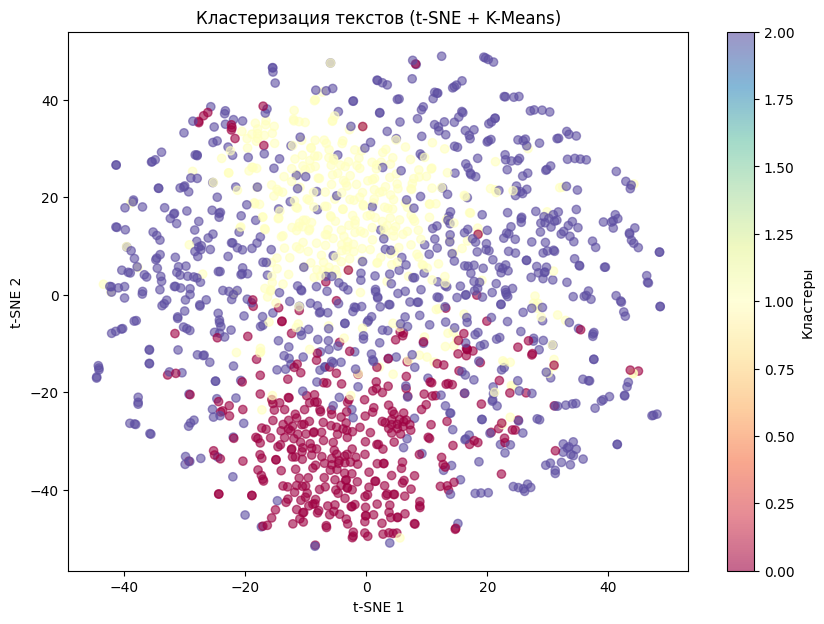

In [175]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

vectorizer = TfidfVectorizer() 
X = vectorizer.fit_transform(df['processed_summary'])
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X)
reducer = TSNE(n_components=2, random_state=42, perplexity=30)
embedding = reducer.fit_transform(X.toarray())
plt.figure(figsize=(10, 7))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=clusters, cmap='Spectral', alpha=0.6)
plt.colorbar(scatter, label='Кластеры')
plt.title('Кластеризация текстов (t-SNE + K-Means)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

Параметр perplexity в t-SNE — это ключевой гиперпараметр, который управляет балансом между локальной и глобальной структурой данных. Его можно интерпретировать как эффективное количество ближайших соседей, которое t-SNE будет учитывать при сохранении расстояний между точками.

## Связь топиков и кластеров

In [182]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['processed_summary'])
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda_doc_topics = lda.fit_transform(X)  # X — из CountVectorizer
df['lda_topic'] = lda_doc_topics.argmax(axis=1)

In [183]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['processed_summary'])
lsa = TruncatedSVD(n_components=3, random_state=42)
lsa_doc_topics = lsa.fit_transform(X)  # X — из TfidfVectorizer
df['lsa_topic'] = lsa_doc_topics.argmax(axis=1)

In [184]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

In [185]:
df.head()

,Title,Abstract,Publication date,Volume,Issue,Publication Type,Authors,Times cited,Fields of Research (ANZSRC 2020),Sustainable Development Goals,original_summary,processed_summary,russian_summary,lda_topic,lsa_topic,cluster
0,Implications of large language models such as ChatGPT for dental medicine,"OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine.\nOVERVIEW: ChatGPT, a LLM trained on massive amounts of textual data, is adept at fulfilling various language-related tasks. Despite its impressive capabilities...",2023-04-05,35,7,Article,"Eggmann, Florin; Weiger, Roland; Zitzmann, Nicola U.; Blatz, Markus B.",163,32 Biomedical and Clinical Sciences; 3203 Dentistry,NaN,"[OBJECTIVE: This article provides an overview of the implications of ChatGPT and other large language models (LLMs) for dental medicine., CONCLUSIONS: While LLMs such as ChatGPT may have various useful applications in dental medicine, they come with risks of malicious use and serious limitations...",objective article provides overview implication chatgpt large language model llm dental medicine . conclusion llm chatgpt may various useful application dental medicine come risk malicious use serious limitation including potential misinformation . clinical significance along potential benefit u...,"ОБЕКТИВ: Эта статья дает обзор последствий ChatGPT и других крупных языковых моделей (LLLLM) для стоматологической медицины. ВЫВОДЫ: В то время как LLLM, такие как ChatGPT могут иметь различные полезные применения в стоматологической медицине, они могут быть, они связаны с рической медициной, он...",1,0,1
1,Assessing the Utilization of Large Language Models in Medical Education: Insights From Undergraduate Medical Students,"Background Artificial intelligence (AI) has the potential to be integrated into medical education. Among AI-based technology, large language models (LLMs) such as ChatGPT, Google Bard, Microsoft Bing, and Perplexity have emerged as powerful tools with capabilities in natural language processing....",2023-10-22,15,10,Article,"Biri, Sairavi Kiran; Kumar, Subir; Panigrahi, Muralidhar; Mondal, Shaikat; Behera, Joshil Kumar; Mondal, Himel",16,32 Biomedical and Clinical Sciences; 3202 Clinical Sciences,4 Quality Education,"[With this background, this study investigates the knowledge, attitude, and practice of undergraduate medical students regarding the utilization of LLMs in medical education in a medical college in Jharkhand, India., The overall score of knowledge (3.21±0.55), attitude (3.47±0.54), and practice ...",background study investigates knowledge attitude practice undergraduate medical student regarding utilization llm medical education medical college jharkhand india . result total 172 student participated study response rate 46.49. majority student 45.93 rarely used llm teachinglearning purpose c...,"На этом фоне данное исследование исследует знания, отношение и практику студентов медицинских факультетов к использованию LLLM в медицинском образовании в медицинском образовании в медицинском колледже в Джаркханде (Джарханде, Индия). Общий балл знаний (3,21 ± 0,55), отношения (3,47 ± 0,54) и пр...",0,0,0
2,Leveraging Large Language Models for Decision Support in Personalized Oncology,Importance: Clinical interpretation of complex biomarkers for precision oncology currently requires manual investigations of previous studies and databases. Conversational large language models (LLMs) might be beneficial as automated tools for assisting clinical decision-making.\nObjective: To a...,2023-11-01,6,11,Article,"Benary, Manuela; Wang, Xing David; Schmidt, Max; Soll, Dominik; Hilfenhaus, Georg; Nassir, Mani; Sigler, Christian; Knödler, Maren; Keller, Ulrich; Beule, Dieter; Keilholz, Ulrich; Leser, Ulf; Rieke, Damian T.",126,32 Biomedical and Clinical Sciences; 3211 Oncology and Carcinogenesis,3 Good Health and Well Being,"[Treatment options were masked and presented to a molecu

In [186]:
df['lsa_topic'].value_counts()

lsa_topic
0    1343
1     123
2      34
Name: count, dtype: int64

In [187]:
df['lda_topic'].value_counts()

lda_topic
1    693
2    407
0    400
Name: count, dtype: int64

In [188]:
df['cluster'].value_counts()

cluster
2    736
0    384
1    380
Name: count, dtype: int64

In [189]:
print("Согласованность LDA topic vs Cluster")
print(pd.crosstab(df['lda_topic'], df['cluster'], normalize='index'))


print("\nСогласованность LSA topic vs Cluster")
print(pd.crosstab(df['lsa_topic'], df['cluster'], normalize='index'))

Согласованность LDA topic vs Cluster
cluster           0         1         2
lda_topic                              
0          0.765000  0.005000  0.230000
1          0.095238  0.532468  0.372294
2          0.029484  0.022113  0.948403

Согласованность LSA topic vs Cluster
cluster           0         1         2
lsa_topic                              
0          0.192107  0.263589  0.544304
1          0.983740  0.000000  0.016260
2          0.147059  0.764706  0.088235
